# NB06 — Functional and territorial context of charging-station patterns

## Structure

6.1 Objective  
6.2 Data preparation  
6.3 Distribution by COS2018 land-cover class  
6.4 COS2018 × LISA patterns  
6.5 COS2018 × K-Means typologies  
6.6 Proximity to the road network  
6.7 Case study: District of Coimbra  
6.8 Complementary synthesis and exports


In [1]:
# ---------------------------------------
#           Setup e ligação à DB
# ---------------------------------------

import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely import wkb, wkt
from shapely.geometry.base import BaseGeometry
from sqlalchemy import create_engine

# Project root
project_path = os.path.abspath(
    os.path.join(os.getcwd(), "..")
)

if project_path not in sys.path:
    sys.path.append(project_path)

from db.config import DB_CONFIG

FIG_DIR = Path("../outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

TABLE_DIR = Path("../outputs/tables")
TABLE_DIR.mkdir(parents=True, exist_ok=True)

def get_engine():
    return create_engine(
        f"postgresql+psycopg2://"
        f"{DB_CONFIG['user']}:{DB_CONFIG['password']}@"
        f"{DB_CONFIG['host']}:{DB_CONFIG['port']}/"
        f"{DB_CONFIG['dbname']}"
    )

engine = get_engine()

print("Libraries and database connection configured.")


Libraries and database connection configured.


In [2]:
# ---------------------------------------
# Funções auxiliares
# ---------------------------------------

DISTRITO = "Coimbra"
EXPECTED_STATIONS = 9309

def read_sql(query):
    return pd.read_sql(query, engine)

def read_gdf(query, geom_col="geom"):
    return gpd.read_postgis(
        query,
        engine,
        geom_col=geom_col
    )

def anonymise_station_labels(df, id_col="id_charging_station", label_col="station_label"):
    """
        Creates anonymised station labels for sensivel data
    """
    df_out = df.copy()

    df_out[label_col] = [
        f"CS{i:03d}"
        for i in range(1, len(df_out) + 1)
    ]

    return df_out


In [3]:
# -------------------------------------------------
# Mapeamento overleaf (EN)
# -------------------------------------------------

COS_LABELS_EN = {
    "Territórios artificializados": "Artificial surfaces",
    "Agricultura": "Agricultural areas",
    "Florestas": "Forests",
    "Matos": "Shrubland",
    "Pastagens": "Pastures",
    "Massas de água superficiais": "Surface water bodies",
    "Superfícies agroflorestais (SAF)": "Agroforestry areas (SAF)",
    "Zonas húmidas": "Wetlands",
    "Espaços descobertos ou com pouca vegetação":
        "Open spaces with little or no vegetation"
}

## 6.1 Objective

This notebook provides a complementary functional and territorial interpretation of the spatial patterns identified in NB05. It examines whether LISA patterns, K-Means typologies and priority stations are associated with specific land-cover contexts and road-network characteristics.

The analyses in this notebook do not redefine the priority criteria or retrain the clustering model. They contextualise the national results obtained previously.


## 6.2 Data preparation


In [4]:
# -------------------------------------------------
# COS2018 context with station geometry
# -------------------------------------------------
cos = read_gdf(
    "SELECT * FROM v65_cos2018_posto",
    geom_col="geom"
)

# Final RQ3 results exported by NB05
rq3_context = pd.read_csv(
    "../outputs/rq3_context.csv"
)


rq3_cols = [
    "id_charging_station",
    "cluster",
    "lisa_quadrant",
    "lisa_pvalue",
    "lisa_significant",
    "lisa_class",
    "sessoes_mes_ativo",
    "sessoes_por_evse_instalado",
    "kwh_por_kw_instalado"
]

rq3_context_clean = rq3_context[rq3_cols].copy()

#--- 
"""
required_rq3_cols = {
    "id_charging_station",
    "cluster",
    "lisa_class"
}

missing_rq3_cols = (
    required_rq3_cols
    - set(rq3_context.columns)
)

if missing_rq3_cols:
    raise KeyError(
        f"Missing columns in rq3_context.csv: "
        f"{sorted(missing_rq3_cols)}"
    )
"""
# ---

# Inner merge deliberately restricts this notebook to the
# 9,309 stations analysed in NB05.
gdf = (
    cos
    .merge(
        rq3_context_clean,
        on="id_charging_station",
        how="inner",
        validate="one_to_one"
    )
)

gdf = gpd.GeoDataFrame(
    gdf,
    geometry="geom",
    crs=cos.crs
)

# print(gdf.columns.tolist())

print(f"COS records: {len(cos):,}")
print(f"RQ3 stations: {len(rq3_context):,}")
print(f"Integrated stations: {len(gdf):,}")
print(f"CRS: {gdf.crs}")


COS records: 16,674
RQ3 stations: 9,309
Integrated stations: 9,309
CRS: EPSG:3763


In [5]:
assert len(gdf) == EXPECTED_STATIONS
assert gdf["id_charging_station"].is_unique
assert gdf.geometry.notna().all()
assert gdf["cluster"].notna().all()
assert gdf["lisa_class"].notna().all()

print("Integrated NB06 dataset validated.")


Integrated NB06 dataset validated.


In [6]:
# Priority-station identifiers exported by NB05
priority_ids = pd.read_csv(
    "../outputs/rq3_priority_stations.csv",
    usecols=["id_charging_station"]
)

priority_id_set = set(
    priority_ids["id_charging_station"]
)

gdf["is_priority"] = (
    gdf["id_charging_station"]
    .isin(priority_id_set)
)

print(
    "Priority stations matched: "
    f"{gdf['is_priority'].sum():,}"
)


Priority stations matched: 185


## 6.3 Distribution by COS2018 land-cover class


In [7]:
cos_distribution = (
    gdf["cos18n1_l"]
    .value_counts(dropna=False)
    .rename_axis("COS2018 class")
    .reset_index(name="Stations")
)

cos_distribution["Percentage"] = (
    cos_distribution["Stations"]
    / len(gdf)
    * 100
)

display(cos_distribution.round(2))


,COS2018 class,Stations,Percentage
0,Territórios artificializados,8592,92.30
1,Agricultura,299,3.21
2,Florestas,180,1.93
3,Matos,179,1.92
4,Pastagens,41,0.44
5,Massas de água superficiais,12,0.13
6,Superfícies agroflorestais (SAF),4,0.04
7,Zonas húmidas,1,0.01
8,Espaços descobertos ou com pouca vegetação,1,0.01


In [8]:
cos_plot = (
    cos_distribution
    .copy()
)

cos_plot["COS2018 class"] = (
    cos_plot["COS2018 class"]
    .replace(COS_LABELS_EN)
)

cos_plot = (
    cos_plot
    .sort_values("Percentage", ascending=True)
)

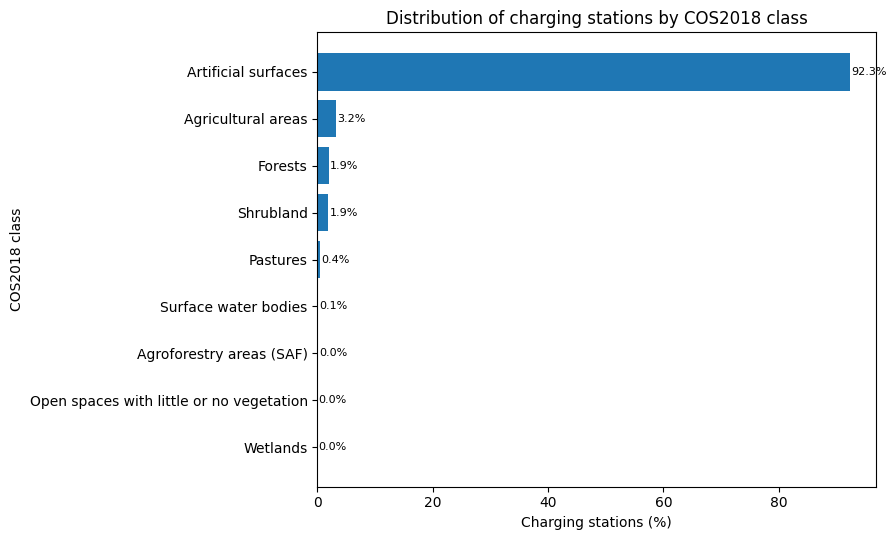

In [9]:
fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.barh(
    cos_plot["COS2018 class"].astype(str),
    cos_plot["Percentage"]
)

for bar, value in zip(
    bars,
    cos_plot["Percentage"]
):
    ax.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        fontsize=8
    )

ax.set_title(
    "Distribution of charging stations by COS2018 class"
)

ax.set_xlabel("Charging stations (%)")
ax.set_ylabel("COS2018 class")

plt.tight_layout()

fig.savefig(
    FIG_DIR / "cos2018_station_distribution_nb06.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 6.4 COS2018 × LISA patterns

Two complementary normalisations are used:

- **row-normalised:** distribution of LISA classes within each COS2018 class;
- **column-normalised:** land-cover composition of each LISA class.


In [10]:
LISA_ORDER = [
    "High-High",
    "High-Low",
    "Low-High",
    "Low-Low",
    "Not significant"
]

cos_lisa_counts = pd.crosstab(
    gdf["cos18n1_l"],
    gdf["lisa_class"]
).reindex(
    columns=LISA_ORDER,
    fill_value=0
)

cos_lisa_within_cos = (
    pd.crosstab(
        gdf["cos18n1_l"],
        gdf["lisa_class"],
        normalize="index"
    )
    .reindex(columns=LISA_ORDER, fill_value=0)
    .mul(100)
    .round(2)
)

cos_lisa_within_lisa = (
    pd.crosstab(
        gdf["cos18n1_l"],
        gdf["lisa_class"],
        normalize="columns"
    )
    .reindex(columns=LISA_ORDER, fill_value=0)
    .mul(100)
    .round(2)
)

display(cos_lisa_counts)
display(cos_lisa_within_cos)
display(cos_lisa_within_lisa)


lisa_class,High-High,High-Low,Low-High,Low-Low,Not significant
cos18n1_l,,,,,
Agricultura,1,9,19,65,205
Espaços descobertos ou com pouca vegetação,0,0,0,0,1
Florestas,6,4,3,37,130
Massas de água superficiais,0,0,1,5,6
Matos,5,4,6,74,90
Pastagens,1,2,2,2,34
Superfícies agroflorestais (SAF),0,0,0,1,3
Territórios artificializados,606,154,462,1250,6120
Zonas húmidas,0,0,0,0,1


lisa_class,High-High,High-Low,Low-High,Low-Low,Not significant
cos18n1_l,,,,,
Agricultura,0.33,3.01,6.35,21.74,68.56
Espaços descobertos ou com pouca vegetação,0.00,0.00,0.00,0.00,100.00
Florestas,3.33,2.22,1.67,20.56,72.22
Massas de água superficiais,0.00,0.00,8.33,41.67,50.00
Matos,2.79,2.23,3.35,41.34,50.28
Pastagens,2.44,4.88,4.88,4.88,82.93
Superfícies agroflorestais (SAF),0.00,0.00,0.00,25.00,75.00
Territórios artificializados,7.05,1.79,5.38,14.55,71.23
Zonas húmidas,0.00,0.00,0.00,0.00,100.00


lisa_class,High-High,High-Low,Low-High,Low-Low,Not significant
cos18n1_l,,,,,
Agricultura,0.16,5.20,3.85,4.53,3.11
Espaços descobertos ou com pouca vegetação,0.00,0.00,0.00,0.00,0.02
Florestas,0.97,2.31,0.61,2.58,1.97
Massas de água superficiais,0.00,0.00,0.20,0.35,0.09
Matos,0.81,2.31,1.22,5.16,1.37
Pastagens,0.16,1.16,0.41,0.14,0.52
Superfícies agroflorestais (SAF),0.00,0.00,0.00,0.07,0.05
Territórios artificializados,97.90,89.02,93.71,87.17,92.87
Zonas húmidas,0.00,0.00,0.00,0.00,0.02


In [11]:
hotspots = gdf[
    gdf["lisa_class"] == "High-High"
].copy()

cos_compare = pd.DataFrame({
    "Network (%)":
        gdf["cos18n1_l"]
        .value_counts(normalize=True)
        * 100,

    "High-High (%)":
        hotspots["cos18n1_l"]
        .value_counts(normalize=True)
        * 100
}).fillna(0)

cos_compare["Difference (pp)"] = (
    cos_compare["High-High (%)"]
    - cos_compare["Network (%)"]
)

cos_compare = (
    cos_compare
    .sort_values(
        "Difference (pp)",
        ascending=False
    )
    .round(2)
)

display(cos_compare)


,Network (%),High-High (%),Difference (pp)
cos18n1_l,,,
Territórios artificializados,92.30,97.90,5.60
Espaços descobertos ou com pouca vegetação,0.01,0.00,-0.01
Zonas húmidas,0.01,0.00,-0.01
Superfícies agroflorestais (SAF),0.04,0.00,-0.04
Massas de água superficiais,0.13,0.00,-0.13
Pastagens,0.44,0.16,-0.28
Florestas,1.93,0.97,-0.96
Matos,1.92,0.81,-1.12
Agricultura,3.21,0.16,-3.05


In [12]:
cos_compare_plot = (
    cos_compare
    .copy()
)

cos_compare_plot.index = (
    cos_compare_plot.index
    .to_series()
    .replace(COS_LABELS_EN)
)

cos_compare_plot = (
    cos_compare_plot
    .sort_values("Difference (pp)", ascending=True)
)

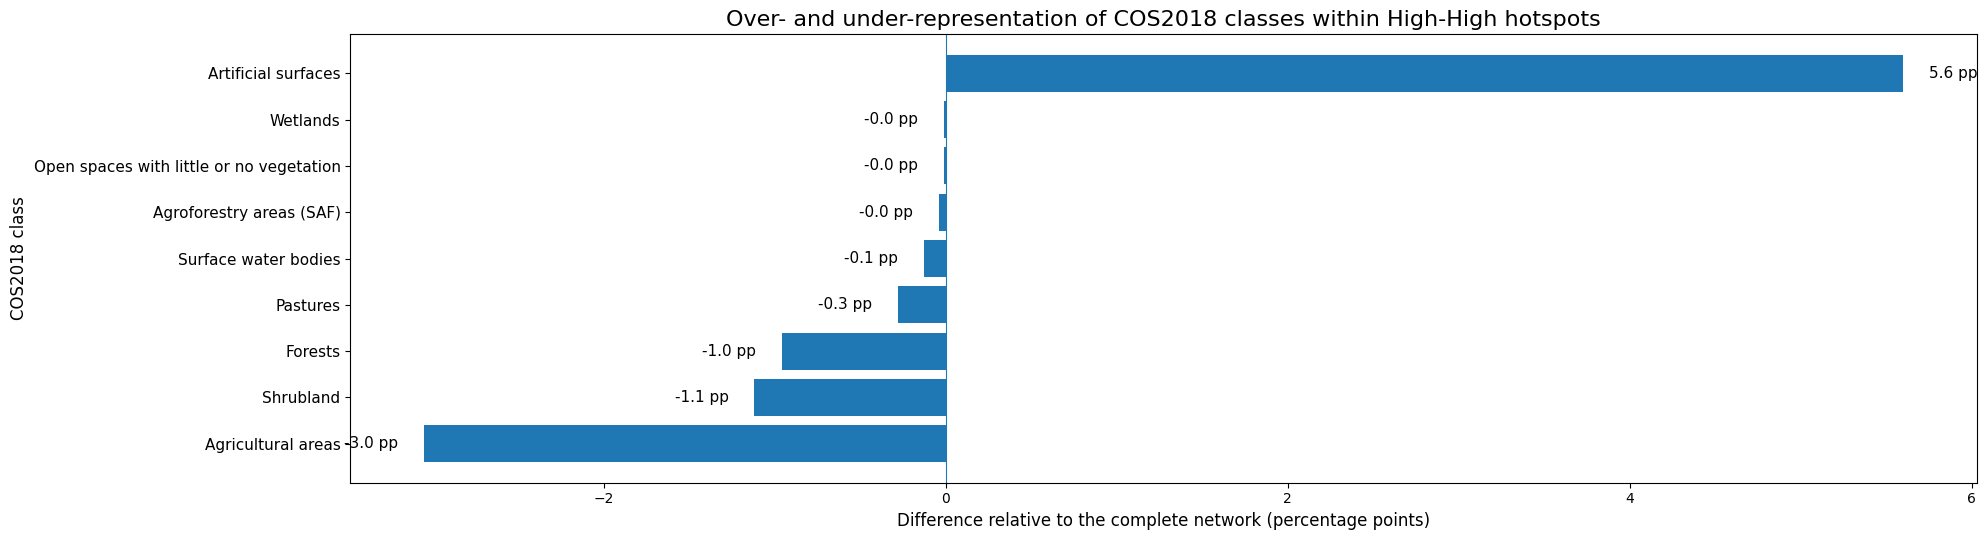

In [13]:
fig, ax = plt.subplots(figsize=(20, 5.5))

bars = ax.barh(
    cos_compare_plot.index,
    cos_compare_plot["Difference (pp)"]
)

for bar, value in zip(
    bars,
    cos_compare_plot["Difference (pp)"]
):
    offset = 0.15 if value >= 0 else -0.15
    alignment = "left" if value >= 0 else "right"

    ax.text(
        bar.get_width() + offset,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f} pp",
        va="center",
        ha=alignment,
        fontsize=11
    )

ax.axvline(0, linewidth=0.8)

ax.set_title(
    "Over- and under-representation of COS2018 classes "
    "within High-High hotspots", fontsize=16
)

ax.set_xlabel(
    "Difference relative to the complete network "
    "(percentage points)", fontsize=12
)

ax.set_ylabel("COS2018 class", fontsize=12)
ax.tick_params(axis="y", labelsize=11)

plt.tight_layout()

fig.savefig(
    FIG_DIR / "cos2018_high_high_over_under_representation_nb06_4.21.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 6.5 COS2018 × K-Means typologies


In [14]:
cluster_cos = (
    pd.crosstab(
        gdf["cluster"],
        gdf["cos18n1_l"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

display(cluster_cos)


cos18n1_l,Agricultura,Espaços descobertos ou com pouca vegetação,Florestas,Massas de água superficiais,Matos,Pastagens,Superfícies agroflorestais (SAF),Territórios artificializados,Zonas húmidas
cluster,,,,,,,,,
0,1.73,0.03,1.24,0.14,1.65,0.22,0.00,94.99,0.00
1,4.35,0.00,2.16,0.08,2.12,0.65,0.12,90.53,0.00
2,3.43,0.00,3.18,0.42,2.76,0.33,0.08,89.71,0.08
3,4.36,0.00,2.18,0.00,1.65,0.64,0.00,91.17,0.00


In [15]:
cos_labels_en = {
    "Territórios artificializados": "Artificial surfaces",
    "Agricultura": "Agricultural areas",
    "Florestas": "Forests",
    "Matos": "Shrublands"
}

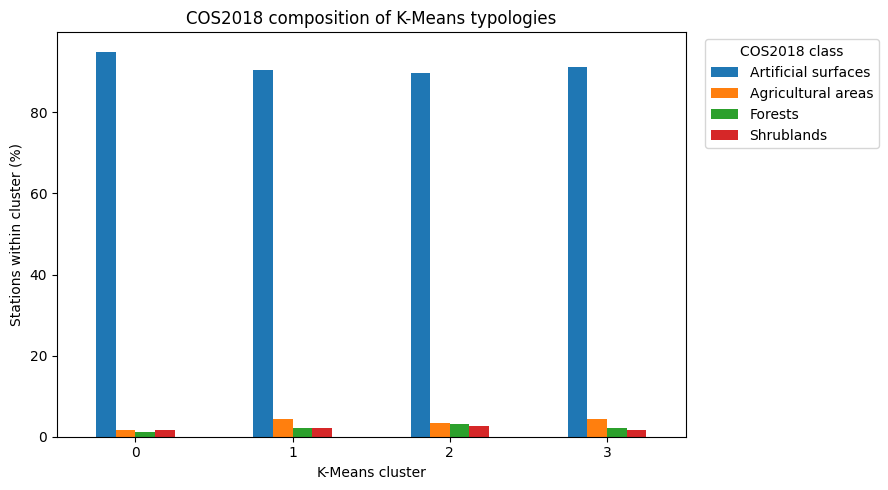

In [16]:
main_cos_classes = [
    col
    for col in [
        "Territórios artificializados",
        "Agricultura",
        "Florestas",
        "Matos"
    ]
    if col in cluster_cos.columns
]

cluster_cos_plot = (
    cluster_cos[main_cos_classes]
    .rename(columns=cos_labels_en)
)

fig, ax = plt.subplots(figsize=(9, 5))

cluster_cos_plot.plot(
    kind="bar",
    ax=ax
)

ax.set_title(
    "COS2018 composition of K-Means typologies"
)

ax.set_xlabel("K-Means cluster")
ax.set_ylabel("Stations within cluster (%)")

ax.tick_params(axis="x", rotation=0)

ax.legend(
    title="COS2018 class",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

fig.savefig(
    FIG_DIR / "cos2018_by_kmeans_cluster_nb06.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 6.6 Proximity to the road network


In [18]:
vias_posto = read_sql(
    '''
    SELECT
        id_charging_station,
        road_number,
        categoria,
        estado,
        gestao,
        n_vias,
        dist_via_m
    FROM v66_posto_rede_viaria_proxima
    '''
)

vias_posto = (
    vias_posto
    .drop_duplicates("id_charging_station")
    .copy()
)

assert vias_posto[
    "id_charging_station"
].is_unique

road_cols_to_add = [
    col
    for col in vias_posto.columns
    if col != "id_charging_station"
    and col not in gdf.columns
]

gdf = gdf.merge(
    vias_posto[
        ["id_charging_station"]
        + road_cols_to_add
    ],
    on="id_charging_station",
    how="left",
    validate="one_to_one"
)

gdf = gpd.GeoDataFrame(
    gdf,
    geometry="geom",
    crs=cos.crs
)

print(
    f"Stations with nearest-road information: " 
    f"{gdf['dist_via_m'].notna().sum():,}"
)


Stations with nearest-road information: 9,309


### 6.6.1 Category of the nearest road


In [19]:
road_category_summary = (
    gdf["categoria"]
    .value_counts(dropna=False)
    .rename_axis("Road category")
    .reset_index(name="Stations")
)

road_category_summary["Percentage"] = (
    road_category_summary["Stations"]
    / len(gdf)
    * 100
)

display(road_category_summary.round(2))


,Road category,Stations,Percentage
0,Estrada Nacional,5166,55.49
1,Ramos de Ligação,1620,17.40
2,Auto-estrada,1082,11.62
3,Estrada Regional,796,8.55
4,Itinerário Principal,417,4.48
5,Itinerário Complementar,225,2.42
6,Caminho Paralelo,3,0.03


In [20]:
ROAD_CATEGORY_EN = {
    "Estrada Nacional": "National Road",
    "Ramos de Ligação": "Link Road",
    "Auto-estrada": "Motorway",
    "Estrada Regional": "Regional Road",
    "Itinerário Principal": "Primary Route",
    "Itinerário Complementar": "Complementary Route",
    "Caminho Paralelo": "Parallel Road"
}

In [21]:
road_category_plot = (
    road_category_summary
    .dropna(subset=["Road category"])
    .copy()
)

road_category_plot["Road category"] = (
    road_category_plot["Road category"]
    .replace(ROAD_CATEGORY_EN)
)

road_category_plot = (
    road_category_plot
    .sort_values("Percentage", ascending=True)
)

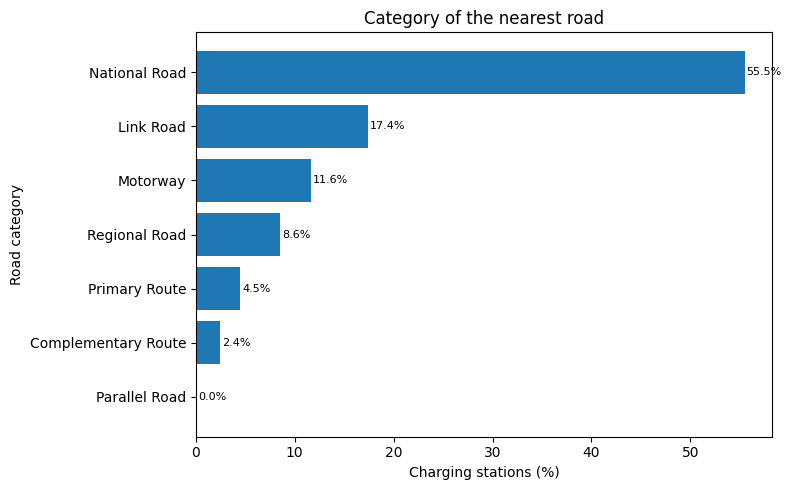

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.barh(
    road_category_plot["Road category"],
    road_category_plot["Percentage"]
)

for bar, value in zip(
    bars,
    road_category_plot["Percentage"]
):
    ax.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        fontsize=8
    )

ax.set_title(
    "Category of the nearest road"
)

ax.set_xlabel("Charging stations (%)")
ax.set_ylabel("Road category")

plt.tight_layout()

fig.savefig(
    FIG_DIR / "nearest_road_category_nb06.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


### 6.6.2 Road category × LISA pattern


In [23]:
ROAD_CATEGORY_EN = {
    "Estrada Nacional": "National Road (EN)",
    "Ramos de Ligação": "Connecting Ramps",
    "Auto-estrada": "Motorway (A)",
    "Estrada Regional": "Regional Road (ER)",
    "Itinerário Principal": "Main Trunk Road (IP)",
    "Itinerário Complementar": "Complementary Trunk Road (IC)",
    "Caminho Paralelo": "Parallel Service Road"
}

In [24]:
road_lisa_pct = (
    pd.crosstab(
        gdf["categoria"],
        gdf["lisa_class"],
        normalize="columns"
    )
    .reindex(columns=LISA_ORDER, fill_value=0)
    .mul(100)
    .round(2)
)

display(road_lisa_pct)


lisa_class,High-High,High-Low,Low-High,Low-Low,Not significant
categoria,,,,,
Auto-estrada,25.53,6.36,15.42,7.46,11.08
Caminho Paralelo,0.00,0.00,0.00,0.00,0.05
Estrada Nacional,31.18,63.01,45.03,53.70,58.76
Estrada Regional,1.94,11.56,4.46,8.51,9.41
Itinerário Complementar,2.91,4.62,1.42,3.63,2.12
Itinerário Principal,5.82,3.47,7.10,8.72,3.26
Ramos de Ligação,32.63,10.98,26.57,17.99,15.33


In [25]:
road_lisa_report = road_lisa_pct.copy()

road_lisa_report.index = (
    road_lisa_report.index
    .to_series()
    .replace(ROAD_CATEGORY_EN)
)

display(road_lisa_report)

values = road_lisa_report.values

lisa_class,High-High,High-Low,Low-High,Low-Low,Not significant
categoria,,,,,
Motorway (A),25.53,6.36,15.42,7.46,11.08
Parallel Service Road,0.00,0.00,0.00,0.00,0.05
National Road (EN),31.18,63.01,45.03,53.70,58.76
Regional Road (ER),1.94,11.56,4.46,8.51,9.41
Complementary Trunk Road (IC),2.91,4.62,1.42,3.63,2.12
Main Trunk Road (IP),5.82,3.47,7.10,8.72,3.26
Connecting Ramps,32.63,10.98,26.57,17.99,15.33


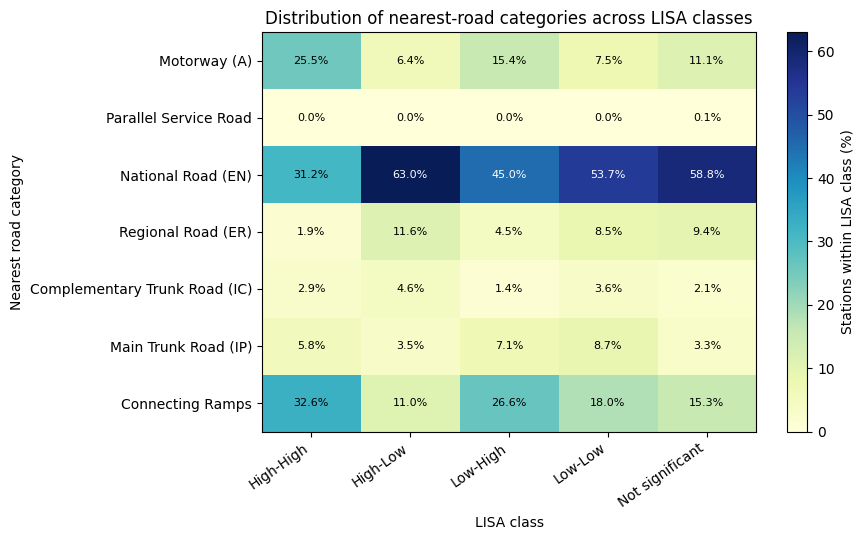

In [26]:
road_lisa_report = road_lisa_pct.copy()

road_lisa_report.index = (
    road_lisa_report.index
    .to_series()
    .replace(ROAD_CATEGORY_EN)
)

# display(road_lisa_report)

values = road_lisa_report.values

fig, ax = plt.subplots(figsize=(9, 5.5))

im = ax.imshow(
    values,
    aspect="auto",
    cmap="YlGnBu"
)

ax.set_xticks(
    range(len(road_lisa_report.columns)),
    labels=road_lisa_report.columns,
    rotation=35,
    ha="right"
)

ax.set_yticks(
    range(len(road_lisa_report.index)),
    labels=road_lisa_report.index
)

norm = im.norm

for i in range(values.shape[0]):
    for j in range(values.shape[1]):
        value = values[i, j]
        ax.text(
            j,
            i,
            f"{value:.1f}%",
            ha="center",
            va="center",
            fontsize=8,
            color=(
                "white"
                if norm(value) > 0.55
                else "black"
            )
        )

ax.set_title(
    "Distribution of nearest-road categories across LISA classes"
)
ax.set_xlabel("LISA class")
ax.set_ylabel("Nearest road category")

fig.colorbar(
    im,
    ax=ax,
    label="Stations within LISA class (%)"
)

plt.tight_layout()

fig.savefig(
    FIG_DIR / "road_category_lisa_heatmap_nb06.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


### 6.6.3 Distance to the nearest road


In [27]:
distance_by_lisa = (
    gdf
    .groupby("lisa_class")["dist_via_m"]
    .agg(["count", "mean", "median", "min", "max"])
    .reindex(LISA_ORDER)
    .round(2)
)

distance_by_cluster = (
    gdf
    .groupby("cluster")["dist_via_m"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

display(distance_by_lisa)
display(distance_by_cluster)


,count,mean,median,min,max
lisa_class,,,,,
High-High,619,453.88,165.61,4.43,4521.60
High-Low,173,467.80,94.95,1.85,5337.81
Low-High,493,546.69,265.10,1.20,4444.14
Low-Low,1434,595.88,318.25,1.12,6906.77
Not significant,6590,447.40,207.43,0.01,6863.50


,count,mean,median,min,max
cluster,,,,,
0,3636,542.36,242.58,0.12,6906.77
1,2598,279.07,85.48,0.64,6182.75
2,1195,536.35,289.73,0.32,6863.50
3,1880,583.15,351.57,0.01,5379.12


/var/folders/_j/l86rjc5j3r75sc4fz_y32m_c0000gn/T/ipykernel_77379/3682493913.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


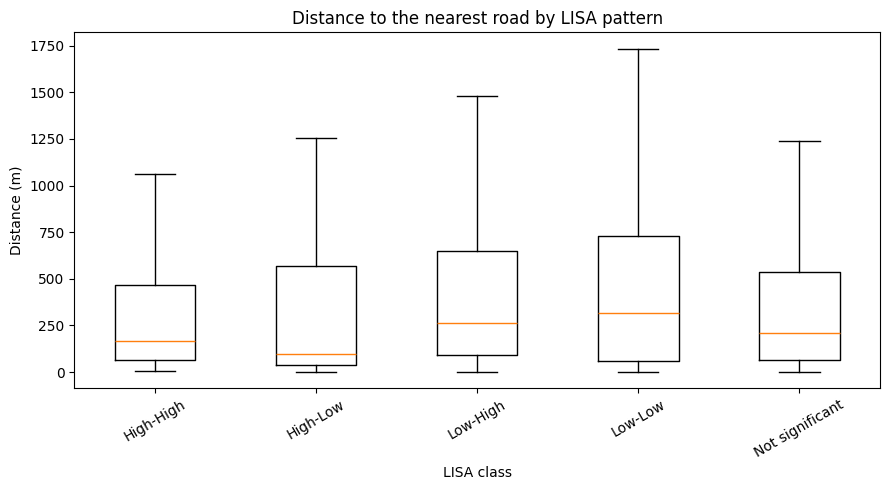

In [28]:
fig, ax = plt.subplots(figsize=(9, 5))

data_lisa = [
    gdf.loc[
        gdf["lisa_class"] == lisa_class,
        "dist_via_m"
    ].dropna().to_numpy()
    for lisa_class in LISA_ORDER
]

ax.boxplot(
    data_lisa,
    labels=LISA_ORDER,
    showfliers=False
)

ax.set_title(
    "Distance to the nearest road by LISA pattern"
)
ax.set_xlabel("LISA class")
ax.set_ylabel("Distance (m)")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()

fig.savefig(
    FIG_DIR / "road_distance_by_lisa_nb06.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


/var/folders/_j/l86rjc5j3r75sc4fz_y32m_c0000gn/T/ipykernel_77379/654158326.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


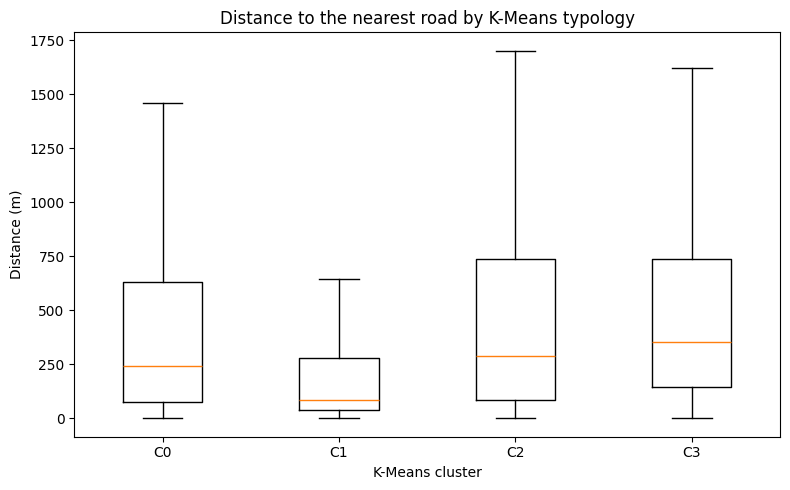

In [29]:
fig, ax = plt.subplots(figsize=(8, 5))

cluster_order = sorted(
    gdf["cluster"].dropna().unique()
)

data_cluster = [
    gdf.loc[
        gdf["cluster"] == cluster_id,
        "dist_via_m"
    ].dropna().to_numpy()
    for cluster_id in cluster_order
]

ax.boxplot(
    data_cluster,
    labels=[
        f"C{int(cluster_id)}"
        for cluster_id in cluster_order
    ],
    showfliers=False
)

ax.set_title(
    "Distance to the nearest road by K-Means typology"
)
ax.set_xlabel("K-Means cluster")
ax.set_ylabel("Distance (m)")

plt.tight_layout()

fig.savefig(
    FIG_DIR / "road_distance_by_cluster_nb06.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


### 6.6.4 Charging network, priority stations and main roads

This map combines the complete charging network, the priority subset identified in NB05 and the main road hierarchy. The map provides spatial context; quantitative evidence of proximity remains based on `dist_via_m`.


In [30]:
# -------------------------------------------------
# Municipal and district boundaries
# -------------------------------------------------

gdf_municipios = read_gdf(
    '''
    SELECT
        distrito,
        municipio,
        geom
    FROM v00_caop_municipios
    WHERE nuts_1 = 'Continente'
    ''',
    geom_col="geom"
).to_crs(gdf.crs)

gdf_distritos = (
    gdf_municipios
    .dissolve(by="distrito")
)

# Original road geometries
gdf_rede_viaria = read_gdf(
    '''
    SELECT
        road_number,
        categoria,
        estado,
        gestao,
        n_vias,
        geom
    FROM rede_rodoviaria
    ''',
    geom_col="geom"
).to_crs(gdf.crs)

display(
    gdf_rede_viaria["categoria"]
    .value_counts(dropna=False)
)


categoria
Estrada Nacional           2194
Estrada Regional            620
Ramos de Ligação            586
Itinerário Complementar     268
Auto-estrada                247
Itinerário Principal         87
Caminho Paralelo             16
NaN                           2
Estrada Desclassificada       1
Name: count, dtype: int64

In [31]:
ROAD_CATEGORY_EN = {
    "Auto-estrada": "Motorway",
    "Itinerário Principal": "Primary Route",
    "Itinerário Complementar": "Complementary Route",
    "Estrada Nacional": "National Road",
    "Estrada Regional": "Regional Road"
}

MAIN_ROAD_STYLES = {
    "Auto-estrada": {
        "linewidth": 0.90,
        "alpha": 0.85
    },
    "Itinerário Principal": {
        "linewidth": 0.70,
        "alpha": 0.75
    },
    "Itinerário Complementar": {
        "linewidth": 0.55,
        "alpha": 0.65
    },
    "Estrada Nacional": {
        "linewidth": 0.30,
        "alpha": 0.45
    },
    "Estrada Regional": {
        "linewidth": 0.20,
        "alpha": 0.35
    }
}

In [32]:
for road_category, style in MAIN_ROAD_STYLES.items():

    road_subset = gdf_rede_viaria[
        gdf_rede_viaria["categoria"] == road_category
    ]

    if road_subset.empty:
        continue

    road_subset.plot(
        ax=ax,
        linewidth=style["linewidth"],
        color="#8c8c8c",
        alpha=style["alpha"],
        label=ROAD_CATEGORY_EN.get(
            road_category,
            road_category
        ),
        zorder=3
    )

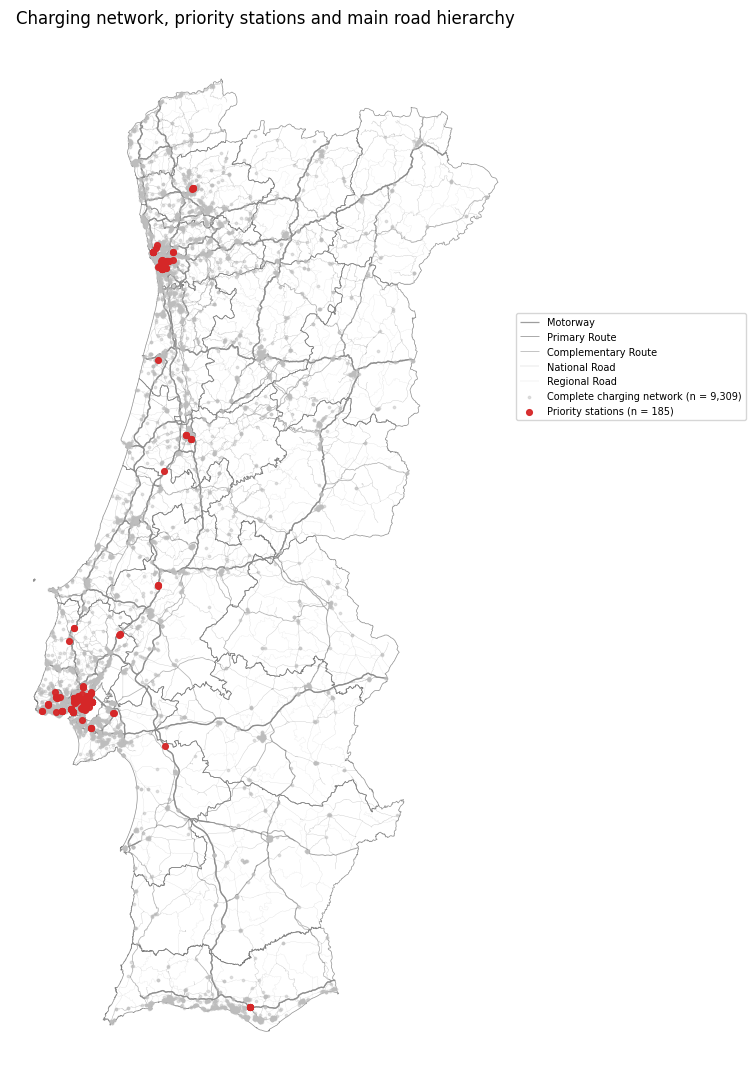

In [33]:
MAIN_ROAD_STYLES = {
    "Auto-estrada": {
        "linewidth": 0.90,
        "alpha": 0.85
    },
    "Itinerário Principal": {
        "linewidth": 0.70,
        "alpha": 0.75
    },
    "Itinerário Complementar": {
        "linewidth": 0.55,
        "alpha": 0.65
    },
    "Estrada Nacional": {
        "linewidth": 0.30,
        "alpha": 0.45
    },
    "Estrada Regional": {
        "linewidth": 0.20,
        "alpha": 0.35
    }
}

priority_gdf = gdf[
    gdf["is_priority"]
].copy()

fig, ax = plt.subplots(figsize=(9, 11))

gdf_municipios.boundary.plot(
    ax=ax,
    linewidth=0.10,
    color="#dddddd",
    alpha=0.7,
    zorder=1
)

gdf_distritos.boundary.plot(
    ax=ax,
    linewidth=0.50,
    color="#777777",
    alpha=0.8,
    zorder=2
)

for road_category, style in MAIN_ROAD_STYLES.items():

    road_subset = gdf_rede_viaria[
        gdf_rede_viaria["categoria"] == road_category
    ]

    if road_subset.empty:
        continue

    road_subset.plot(
        ax=ax,
        linewidth=style["linewidth"],
        color="#8c8c8c",
        alpha=style["alpha"],
        label=ROAD_CATEGORY_EN.get(
            road_category,
            road_category
        ),
        zorder=3
    )

# Complete charging network
gdf.plot(
    ax=ax,
    color="#bdbdbd",
    markersize=3,
    alpha=0.45,
    label=(
        "Complete charging network "
        f"(n = {len(gdf):,})"
    ),
    zorder=4
)

# Priority stations
priority_gdf.plot(
    ax=ax,
    color="#d62728",
    markersize=17,
    alpha=0.95,
    label=(
        "Priority stations "
        f"(n = {len(priority_gdf):,})"
    ),
    zorder=5
)

ax.set_title(
    "Charging network, priority stations and main road hierarchy"
)

ax.legend(
    loc="center left",
    bbox_to_anchor=(0.98, 0.68),
    frameon=True,
    fontsize=7
)

ax.set_axis_off()
plt.tight_layout()

fig.savefig(
    FIG_DIR / "charging_priority_stations_main_roads_nb06.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 6.7 Case study: District of Coimbra


In [34]:
# gdf.columns

In [35]:
gdf_coimbra = gdf[
    gdf["distrito"]
    .str.upper()
    .eq(DISTRITO.upper())
].copy()

print(
    f"Stations in the District of {DISTRITO}: "
    f"{len(gdf_coimbra):,}"
)


Stations in the District of Coimbra: 285


### 6.7.1 COS2018 distribution


In [36]:
coimbra_cos = (
    gdf_coimbra["cos18n1_l"]
    .value_counts()
    .rename_axis("COS2018 class")
    .reset_index(name="Stations")
)

coimbra_cos["Percentage"] = (
    coimbra_cos["Stations"]
    / len(gdf_coimbra)
    * 100
)

display(coimbra_cos.round(2))


,COS2018 class,Stations,Percentage
0,Territórios artificializados,266,93.33
1,Agricultura,11,3.86
2,Florestas,6,2.11
3,Matos,1,0.35
4,Pastagens,1,0.35


### 6.7.2 COS2018 × LISA patterns


In [37]:
# ------------------------------------------------------------
# Distribuição percentual dos valores NaN(16674) e Nulls (0)
# ------------------------------------------------------------

cos_total_pct = (
    gdf_coimbra["cos18n1_l"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

cos_total_pct

cos18n1_l
Territórios artificializados    93.3
Agricultura                      3.9
Florestas                        2.1
Matos                            0.4
Pastagens                        0.4
Name: proportion, dtype: float64

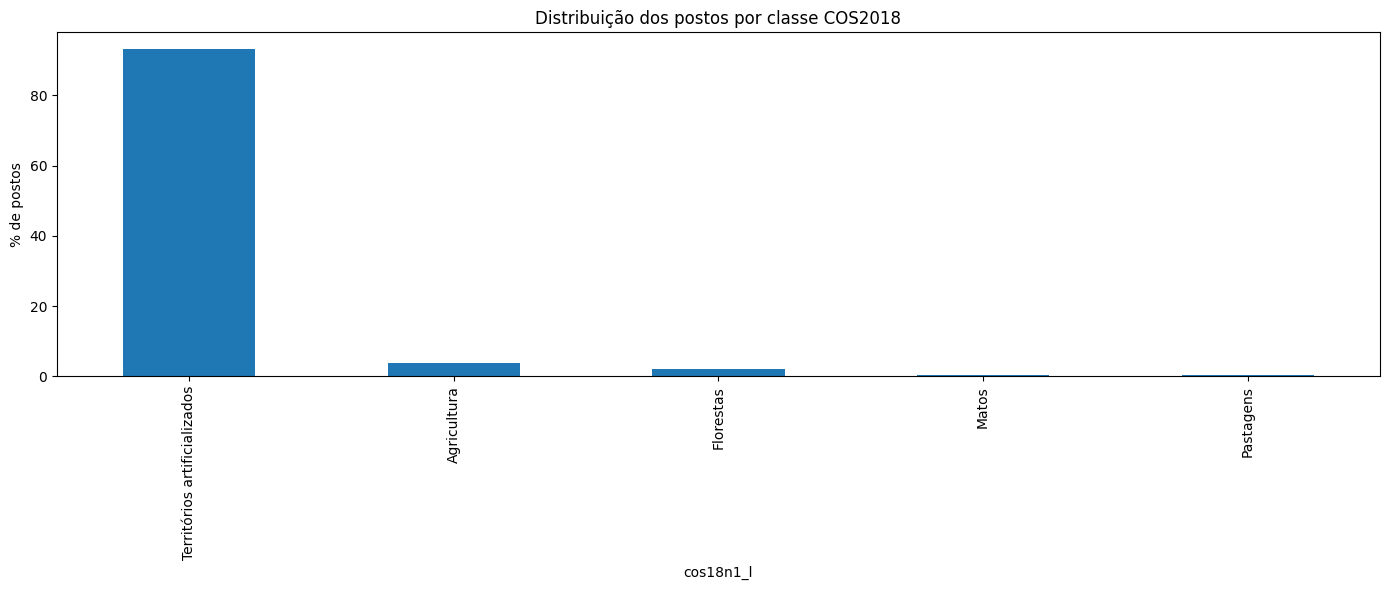

In [38]:
# -------------------------------------------------
# Plot com a distribuição dos postos por COS
# -------------------------------------------------
cos_total_pct.plot.bar(
    figsize=(14,6)
)

plt.title(
    "Distribuição dos postos por classe COS2018"
)

plt.ylabel("% de postos")

plt.tight_layout()
plt.show()

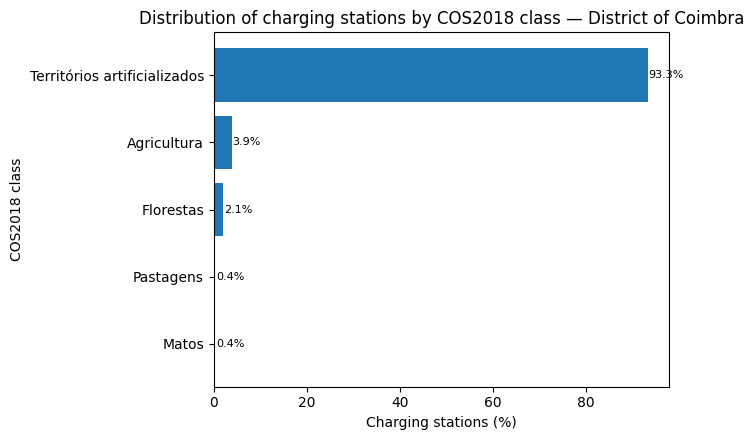

In [39]:
coimbra_cos = (
    gdf_coimbra["cos18n1_l"]
    .value_counts(normalize=True)
    .mul(100)
    .rename_axis("COS2018 class")
    .reset_index(name="Percentage")
)

coimbra_cos = (
    coimbra_cos
    .sort_values("Percentage", ascending=True)
)

fig, ax = plt.subplots(figsize=(7, 4.5))

bars = ax.barh(
    coimbra_cos["COS2018 class"],
    coimbra_cos["Percentage"]
)

for bar, value in zip(bars, coimbra_cos["Percentage"]):
    ax.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        fontsize=8
    )

ax.set_xlabel("Charging stations (%)")
ax.set_ylabel("COS2018 class")

ax.set_title(
    "Distribution of charging stations by COS2018 class — "
    "District of Coimbra"
)

plt.tight_layout()

fig.savefig(
    FIG_DIR / "cos2018_distribution_coimbra_nb06.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

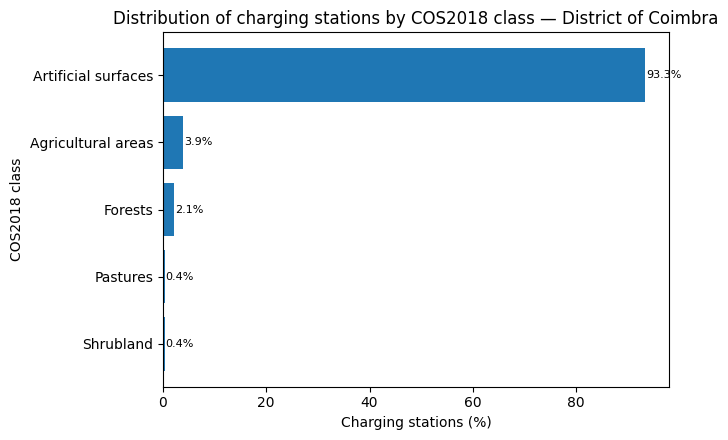

In [40]:
coimbra_cos = (
    gdf_coimbra["cos18n1_l"]
    .value_counts(normalize=True)
    .mul(100)
    .rename_axis("COS2018 class")
    .reset_index(name="Percentage")
)

coimbra_cos["COS2018 class"] = (
    coimbra_cos["COS2018 class"]
    .replace(COS_LABELS_EN)
)

coimbra_cos = (
    coimbra_cos
    .sort_values("Percentage", ascending=True)
)

fig, ax = plt.subplots(figsize=(7, 4.5))

bars = ax.barh(
    coimbra_cos["COS2018 class"],
    coimbra_cos["Percentage"]
)

for bar, value in zip(
    bars,
    coimbra_cos["Percentage"]
):
    ax.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        fontsize=8
    )

ax.set_xlabel("Charging stations (%)")
ax.set_ylabel("COS2018 class")

ax.set_title( "Distribution of charging stations by COS2018 class — District of Coimbra")

plt.tight_layout()

fig.savefig(
    FIG_DIR / "cos2018_distribution_coimbra_nb06.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [41]:
coimbra_territorial_context = read_sql("""
    SELECT
        municipio,
        densidade_hab_km2,
        postos_por_10000_hab,
        evse_por_10000_hab,
        kw_por_10000_hab
    FROM v63_contexto_concelho
    WHERE UPPER(distrito) = 'COIMBRA'
    ORDER BY densidade_hab_km2 DESC
""")

display(
    coimbra_territorial_context
    .rename(
        columns={
            "municipio": "Municipality",
            "densidade_hab_km2": "Population density",
            "postos_por_10000_hab": "Stations / 10k inhabitants",
            "evse_por_10000_hab": "EVSE / 10k inhabitants",
            "kw_por_10000_hab": "kW / 10k inhabitants"
        }
    )
    .round(2)
)

,Municipality,Population density,Stations / 10k inhabitants,EVSE / 10k inhabitants,kW / 10k inhabitants
0,Coimbra,440.88,14.06,29.54,1202.35
1,Figueira da Foz,155.52,10.01,22.56,1567.01
2,Lousã,122.88,11.17,20.58,521.10
3,Condeixa-a-Nova,120.66,15.54,43.03,3715.69
4,Montemor-o-Velho,107.31,8.14,17.50,927.07
5,Mira,97.66,8.26,18.99,1365.48
6,Miranda do Corvo,94.97,8.33,27.50,726.21
7,Cantanhede,87.53,11.98,35.37,3655.68
8,Oliveira do Hospital,82.78,13.39,35.03,1941.80
9,Vila Nova de Poiares,80.55,2.94,8.82,323.39


In [42]:
print(
    "Municipalities:",
    len(coimbra_territorial_context)
)

display(
    coimbra_territorial_context.describe().round(2)
)

Municipalities: 17


,densidade_hab_km2,postos_por_10000_hab,evse_por_10000_hab,kw_por_10000_hab
count,17.00,17.00,17.00,17.00
mean,98.27,9.37,24.13,1359.31
std,96.56,3.54,9.78,1055.66
min,10.30,2.94,8.82,323.39
25%,55.86,6.95,17.50,692.73
50%,82.78,8.33,22.06,979.91
75%,107.31,11.98,31.49,1567.01
max,440.88,15.54,43.03,3715.69


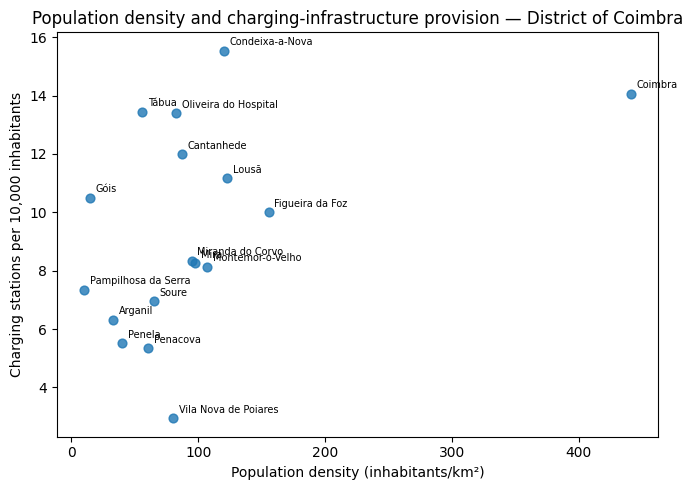

In [43]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    coimbra_territorial_context["densidade_hab_km2"],
    coimbra_territorial_context["postos_por_10000_hab"],
    s=40,
    alpha=0.8
)

for _, row in coimbra_territorial_context.iterrows():
    ax.annotate(
        row["municipio"],
        (
            row["densidade_hab_km2"],
            row["postos_por_10000_hab"]
        ),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=7
    )

ax.set_xlabel("Population density (inhabitants/km²)")
ax.set_ylabel("Charging stations per 10,000 inhabitants")

ax.set_title("Population density and charging-infrastructure provision — District of Coimbra")

plt.tight_layout()

fig.savefig(
    FIG_DIR / "population_density_stations_10k_coimbra_nb06.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [44]:
coimbra_cos_lisa = (
    pd.crosstab(
        gdf_coimbra["cos18n1_l"],
        gdf_coimbra["lisa_class"],
        normalize="columns"
    )
    .reindex(columns=LISA_ORDER, fill_value=0)
    .mul(100)
    .round(2)
)

display(coimbra_cos_lisa)


lisa_class,High-High,High-Low,Low-High,Low-Low,Not significant
cos18n1_l,,,,,
Agricultura,0.0,20.0,5.26,2.38,4.12
Florestas,0.0,0.0,0.00,0.00,3.09
Matos,0.0,0.0,0.00,0.00,0.52
Pastagens,0.0,0.0,0.00,0.00,0.52
Territórios artificializados,100.0,80.0,94.74,97.62,91.75


In [45]:
coimbra_hotspots = gdf_coimbra[
    gdf_coimbra["lisa_class"]
    == "High-High"
].copy()

coimbra_cos_compare = pd.DataFrame({
    "Coimbra network (%)":
        gdf_coimbra["cos18n1_l"]
        .value_counts(normalize=True)
        * 100,

    "Coimbra High-High (%)":
        coimbra_hotspots["cos18n1_l"]
        .value_counts(normalize=True)
        * 100
}).fillna(0)

coimbra_cos_compare["Difference (pp)"] = (
    coimbra_cos_compare["Coimbra High-High (%)"]
    - coimbra_cos_compare["Coimbra network (%)"]
)

display(
    coimbra_cos_compare
    .sort_values(
        "Difference (pp)",
        ascending=False
    )
    .round(2)
)


,Coimbra network (%),Coimbra High-High (%),Difference (pp)
cos18n1_l,,,
Territórios artificializados,93.33,100.0,6.67
Matos,0.35,0.0,-0.35
Pastagens,0.35,0.0,-0.35
Florestas,2.11,0.0,-2.11
Agricultura,3.86,0.0,-3.86


### 6.7.3 Priority stations and road context in Coimbra


In [46]:
coimbra_priority = gdf_coimbra[
    gdf_coimbra["is_priority"]
].copy()


coimbra_priority_display = (
    anonymise_station_labels(
        coimbra_priority
    )
    [
        [
            "station_label",
            "municipio",
            "cluster",
            "lisa_class",
            "categoria",
            "dist_via_m"
        ]
    ]
    .sort_values(
        "dist_via_m",
        ascending=True
    )
)

print(
    f"Priority stations in Coimbra: "
    f"{len(coimbra_priority):,}"
)

display(coimbra_priority_display)


Priority stations in Coimbra: 6


,station_label,municipio,cluster,lisa_class,categoria,dist_via_m
1047,CS001,Coimbra,0,High-High,Itinerário Complementar,178.399807
1051,CS002,Coimbra,0,High-High,Itinerário Complementar,178.399807
1053,CS003,Coimbra,0,High-High,Itinerário Complementar,178.399807
1059,CS004,Coimbra,1,High-High,Itinerário Complementar,526.868333
1060,CS005,Coimbra,1,High-High,Itinerário Complementar,526.868333
1061,CS006,Coimbra,1,High-High,Itinerário Complementar,526.868333


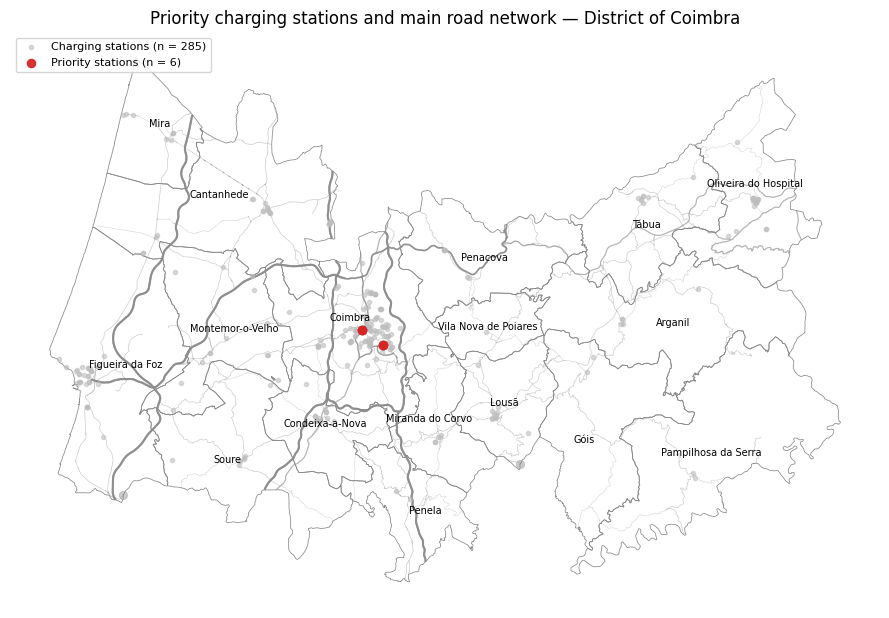

In [47]:
municipios_coimbra = gdf_municipios[
    gdf_municipios["distrito"]
    .str.upper()
    .eq(DISTRITO.upper())
].copy()

roads_coimbra = gdf_rede_viaria.clip(
    municipios_coimbra
)

fig, ax = plt.subplots(figsize=(9, 8))

municipios_coimbra.boundary.plot(
    ax=ax,
    linewidth=0.55,
    color="#888888",
    zorder=1
)

for road_category, style in MAIN_ROAD_STYLES.items():

    road_subset = roads_coimbra[
        roads_coimbra["categoria"] == road_category
    ]

    if road_subset.empty:
        continue

    road_subset.plot(
        ax=ax,
        linewidth=max(
            style["linewidth"] * 1.6,
            0.4
        ),
        color="#8c8c8c",
        alpha=style["alpha"],
        zorder=2
    )

gdf_coimbra.plot(
    ax=ax,
    color="#bdbdbd",
    markersize=9,
    alpha=0.55,
    label=(
        f"Charging stations "
        f"(n = {len(gdf_coimbra):,})"
    ),
    zorder=3
)

coimbra_priority.plot(
    ax=ax,
    color="#d62728",
    markersize=35,
    alpha=0.95,
    label=(
        f"Priority stations "
        f"(n = {len(coimbra_priority):,})"
    ),
    zorder=4
)

geom_col = municipios_coimbra.geometry.name

for _, row in municipios_coimbra.iterrows():

    point = row[geom_col].representative_point()

    ax.text(
        point.x,
        point.y,
        row["municipio"],
        fontsize=7,
        ha="center",
        va="center"
    )

ax.set_title("Priority charging stations and main road network — District of Coimbra")

ax.legend(
    loc="upper left",
    frameon=True,
    fontsize=8
)

ax.set_axis_off()

plt.tight_layout()

fig.savefig(
    FIG_DIR / "coimbra_charging_priority_main_roads_nb06.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 6.9 Export of complementary results


In [48]:
cos_distribution.to_csv(
    TABLE_DIR / "nb06_cos2018_distribution.csv",
    index=False
)

cos_compare.to_csv(
    TABLE_DIR / "nb06_cos2018_high_high_comparison.csv"
)

cluster_cos.to_csv(
    TABLE_DIR / "nb06_cos2018_kmeans_composition.csv"
)

road_lisa_pct.to_csv(
    TABLE_DIR / "nb06_road_category_lisa_composition.csv"
)

distance_by_lisa.to_csv(
    TABLE_DIR / "nb06_road_distance_by_lisa.csv"
)

distance_by_cluster.to_csv(
    TABLE_DIR / "nb06_road_distance_by_cluster.csv"
)

coimbra_cos_compare.to_csv(
    TABLE_DIR / "nb06_coimbra_cos2018_high_high_comparison.csv"
)

print("NB06 outputs exported successfully.")


NB06 outputs exported successfully.
